In [22]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/mubashirsidiki/student-academic-performance-500-students/student_performance.csv


In [82]:
# ─────────────────────────────────────────────────────
# CELL 1: Import Libraries
# ─────────────────────────────────────────────────────
# Data manipulation and numerical computation
import pandas as pd
import numpy as np
import seaborn as sns

# Preprocessing: encode categorical labels and scale numeric features
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Split dataset into training and testing subsets
from sklearn.model_selection import train_test_split

# Classification models
from sklearn.linear_model import LogisticRegression       # Linear baseline model
from sklearn.ensemble import RandomForestClassifier        # Ensemble tree-based model

# Evaluation metrics
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Gradient boosting model (often best for tabular data)
import xgboost as xgb

In [31]:
# ─────────────────────────────────────────────────────
# CELL 2: Load Dataset
# ─────────────────────────────────────────────────────
# Load the student performance CSV file from Kaggle input directory
# Dataset contains 500 students with features like study hours,
# attendance, and whether they passed or not (target variable)
data = pd.read_csv('/kaggle/input/datasets/mubashirsidiki/student-academic-performance-500-students/student_performance.csv')

In [32]:
# ─────────────────────────────────────────────────────
# CELL 3: Preview the Data
# ─────────────────────────────────────────────────────
# Display the first 5 rows to understand the structure,
# column names, and sample values
data.head()

,student_id,gender,age,study_hours_per_week,attendance_rate,parent_education,internet_access,extracurricular,previous_score,final_score,passed
0,STU0001,Male,15,25,63.8,Bachelor,Yes,Yes,41,67,Yes
1,STU0002,Female,15,2,54.7,Bachelor,Yes,Yes,83,28,No
2,STU0003,Female,19,10,90.5,High School,Yes,No,73,49,No
3,STU0004,Male,16,26,66.8,High School,No,Yes,75,70,Yes
4,STU0005,Female,15,25,73.0,High School,No,Yes,67,77,Yes


In [33]:
# ─────────────────────────────────────────────────────
# CELL 4: Dataset Info
# ─────────────────────────────────────────────────────
# Shows column data types, non-null counts, and memory usage
# Helps identify which columns need encoding (object type)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   student_id            500 non-null    object 
 1   gender                500 non-null    object 
 2   age                   500 non-null    int64  
 3   study_hours_per_week  500 non-null    int64  
 4   attendance_rate       500 non-null    float64
 5   parent_education      383 non-null    object 
 6   internet_access       500 non-null    object 
 7   extracurricular       500 non-null    object 
 8   previous_score        500 non-null    int64  
 9   final_score           500 non-null    int64  
 10  passed                500 non-null    object 
dtypes: float64(1), int64(4), object(6)
memory usage: 43.1+ KB


In [34]:
# ─────────────────────────────────────────────────────
# CELL 5: Check for Missing Values
# ─────────────────────────────────────────────────────
# Counts missing values per column
# If any column has nulls, we need to impute or drop them before modeling
data.isnull().sum()

student_id                0
gender                    0
age                       0
study_hours_per_week      0
attendance_rate           0
parent_education        117
internet_access           0
extracurricular           0
previous_score            0
final_score               0
passed                    0
dtype: int64

In [35]:
# ─────────────────────────────────────────────────────
# CELL 6: Drop parent_education Column
# ─────────────────────────────────────────────────────
# Removing 'parent_education' because it has multiple unordered 
# categories that are complex to encode meaningfully at this stage.
# This simplifies the feature set for initial modeling.
data = data.drop(['parent_education'], axis=1)

In [37]:
# ─────────────────────────────────────────────────────
# CELL 7: Drop student_id Column
# ─────────────────────────────────────────────────────
# 'student_id' is just an identifier with no predictive value.
# Including it would confuse the model, so we remove it.
data = data.drop(['student_id'], axis=1)

In [39]:
# ─────────────────────────────────────────────────────
# CELL 8: Verify Columns After Dropping
# ─────────────────────────────────────────────────────
# Confirm the unwanted columns have been removed correctly
data.head()

,gender,age,study_hours_per_week,attendance_rate,internet_access,extracurricular,previous_score,final_score,passed
0,Male,15,25,63.8,Yes,Yes,41,67,Yes
1,Female,15,2,54.7,Yes,Yes,83,28,No
2,Female,19,10,90.5,Yes,No,73,49,No
3,Male,16,26,66.8,No,Yes,75,70,Yes
4,Female,15,25,73.0,No,Yes,67,77,Yes


In [41]:
# ─────────────────────────────────────────────────────
# CELL 9: Check for Duplicate Rows
# ─────────────────────────────────────────────────────
# Duplicate rows can bias the model by overrepresenting certain records.
# If duplicates exist, they should be removed with data.drop_duplicates()
data.duplicated().sum()

np.int64(0)

In [42]:
# ─────────────────────────────────────────────────────
# CELL 10: Statistical Summary
# ─────────────────────────────────────────────────────
# Provides count, mean, std, min, max, and quartiles for numeric columns.
# Useful for spotting outliers or unusual distributions.
data.describe()

,age,study_hours_per_week,attendance_rate,previous_score,final_score
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,16.978000,15.312000,76.380600,62.986000,55.980000
std,1.434445,8.568167,13.817681,18.937451,15.373754
min,15.000000,2.000000,50.200000,30.000000,20.000000
25%,16.000000,8.000000,64.475000,46.000000,45.000000
50%,17.000000,15.000000,76.500000,64.000000,56.000000
75%,18.000000,23.000000,88.525000,79.000000,68.000000
max,19.000000,30.000000,100.000000,95.000000,95.000000


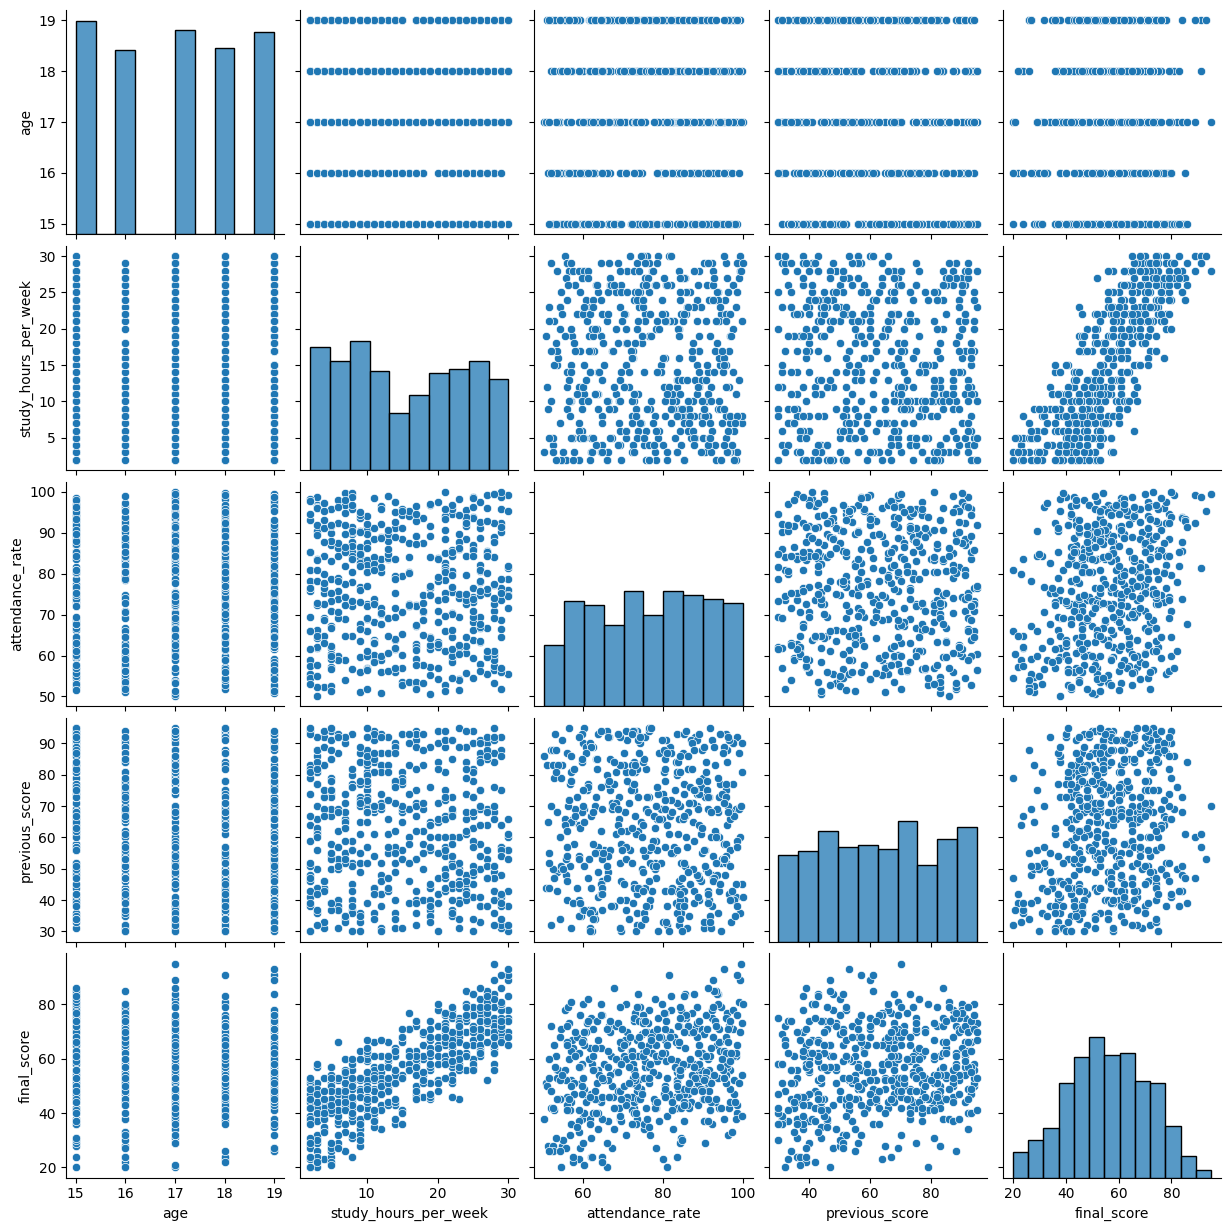

In [48]:
# ─────────────────────────────────────────────────────
# CELL 11: Pairplot - Relationships Between All Features
# ─────────────────────────────────────────────────────
# Visualizes pairwise relationships between all numeric features.
# Helps identify strong linear relationships or clustering patterns
# that may be predictive of the target variable (passed).
sns.pairplot(data);

<Axes: xlabel='final_score', ylabel='Count'>

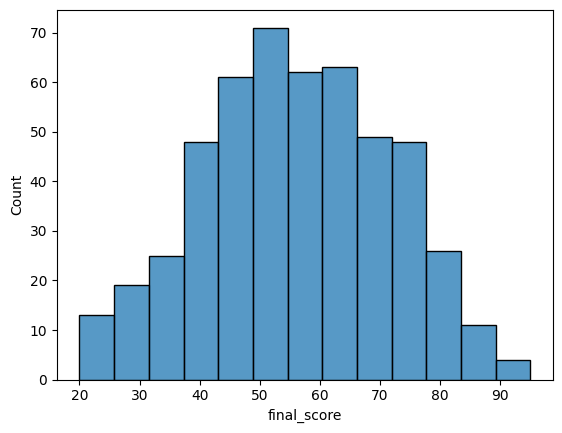

In [50]:
# ─────────────────────────────────────────────────────
# CELL 12: Distribution of Final Score
# ─────────────────────────────────────────────────────
# Plots the distribution of final_score to check if it's 
# normally distributed, skewed, or has any unusual peaks.
sns.histplot(data.final_score)

<Axes: xlabel='attendance_rate', ylabel='final_score'>

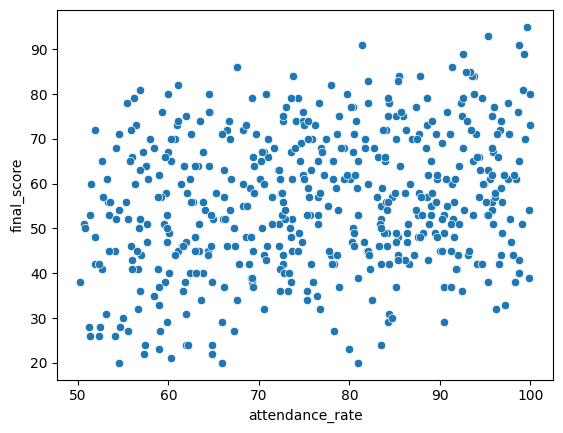

In [55]:
# ─────────────────────────────────────────────────────
# CELL 13: Attendance Rate vs Final Score
# ─────────────────────────────────────────────────────
# Scatter plot to visualize the relationship between attendance 
# and final score. Higher attendance is expected to correlate 
# with better performance.
sns.scatterplot(x=data.attendance_rate, y=data.final_score)

<Axes: xlabel='internet_access', ylabel='count'>

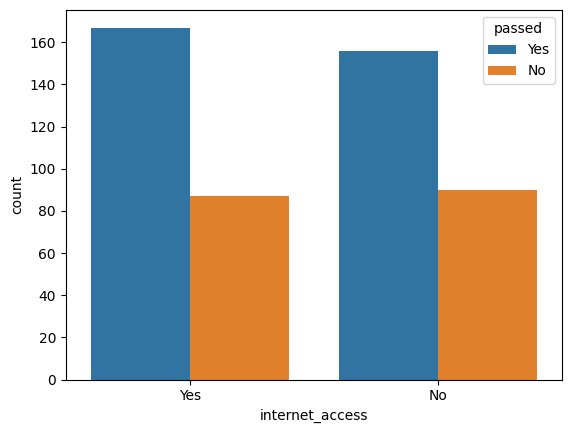

In [59]:
# ─────────────────────────────────────────────────────
# CELL 14: Internet Access vs Passed (Count Plot)
# ─────────────────────────────────────────────────────
# Compares pass/fail counts for students with and without internet access.
# Helps determine if internet access has an impact on student outcomes.
sns.countplot(x='internet_access', hue='passed', data=data)

In [61]:
# ─────────────────────────────────────────────────────
# CELL 15: Correlation Matrix (Numeric Features Only)
# ─────────────────────────────────────────────────────
# Computes Pearson correlation between numeric columns.
# Values close to 1 or -1 indicate strong relationships.
# Note: study_hours_per_week shows ~0.80 correlation with final_score,
# meaning it is the strongest predictor in the dataset.
data.corr(numeric_only=True)

,age,study_hours_per_week,attendance_rate,previous_score,final_score
age,1.000000,-0.055204,0.026155,-0.106613,-0.047819
study_hours_per_week,-0.055204,1.000000,-0.016038,-0.076127,0.803903
attendance_rate,0.026155,-0.016038,1.000000,-0.033069,0.240697
previous_score,-0.106613,-0.076127,-0.033069,1.000000,0.164958
final_score,-0.047819,0.803903,0.240697,0.164958,1.000000


In [64]:
# ─────────────────────────────────────────────────────
# CELL 16: View Column Names
# ─────────────────────────────────────────────────────
# Lists all current column names — useful before applying 
# label encoding to identify which columns are categorical.
data.columns

Index(['gender', 'age', 'study_hours_per_week', 'attendance_rate',
       'internet_access', 'extracurricular', 'previous_score', 'final_score',
       'passed'],
      dtype='object')

In [65]:
# ─────────────────────────────────────────────────────
# CELL 17: Label Encoding for Categorical Columns
# ─────────────────────────────────────────────────────
# Machine learning models require numeric inputs.
# LabelEncoder converts binary categorical columns to 0 and 1:
#   gender:           Male=1, Female=0
#   internet_access:  Yes=1,  No=0
#   extracurricular:  Yes=1,  No=0
#   passed:           Yes=1,  No=0  <-- This is our target variable
le = LabelEncoder()
for col in ['gender', 'internet_access', 'extracurricular', 'passed']:
    data[col] = le.fit_transform(data[col])

In [66]:
# ─────────────────────────────────────────────────────
# CELL 18: Verify Encoding
# ─────────────────────────────────────────────────────
# Confirm categorical columns have been converted to numeric (0/1)
data.head()

,gender,age,study_hours_per_week,attendance_rate,internet_access,extracurricular,previous_score,final_score,passed
0,1,15,25,63.8,1,1,41,67,1
1,0,15,2,54.7,1,1,83,28,0
2,0,19,10,90.5,1,0,73,49,0
3,1,16,26,66.8,0,1,75,70,1
4,0,15,25,73.0,0,1,67,77,1


In [70]:
# ─────────────────────────────────────────────────────
# CELL 19: Full Correlation Matrix (After Encoding)
# ─────────────────────────────────────────────────────
# Now that all columns are numeric, we can compute correlations 
# including the encoded features vs the target variable (passed).
# study_hours_per_week and final_score have the highest correlation 
# with passed (0.65 and 0.79 respectively).
data.corr()

,gender,age,study_hours_per_week,attendance_rate,internet_access,extracurricular,previous_score,final_score,passed
gender,1.000000,0.028015,0.017447,0.001078,0.037636,-0.033247,0.008106,0.031266,0.019808
age,0.028015,1.000000,-0.055204,0.026155,0.043517,-0.037870,-0.106613,-0.047819,-0.046387
study_hours_per_week,0.017447,-0.055204,1.000000,-0.016038,0.040078,0.030815,-0.076127,0.803903,0.655330
attendance_rate,0.001078,0.026155,-0.016038,1.000000,0.059216,-0.043182,-0.033069,0.240697,0.152903
internet_access,0.037636,0.043517,0.040078,0.059216,1.000000,0.068206,0.008365,0.050553,0.024394
extracurricular,-0.033247,-0.037870,0.030815,-0.043182,0.068206,1.000000,0.041752,0.028896,0.028759
previous_score,0.008106,-0.106613,-0.076127,-0.033069,0.008365,0.041752,1.000000,0.164958,0.168127
final_score,0.031266,-0.047819,0.803903,0.240697,0.050553,0.028896,0.164958,1.000000,0.795821
passed,0.019808,-0.046387,0.655330,0.152903,0.024394,0.028759,0.168127,0.795821,1.000000


In [71]:
# ─────────────────────────────────────────────────────
# CELL 20: Drop Low-Correlation Features
# ─────────────────────────────────────────────────────
# Based on the correlation matrix, the following features 
# show very weak correlation with the target (passed):
#   gender, age, internet_access, extracurricular
# Removing them reduces noise and simplifies the model.
data = data.drop(['gender', 'age', 'internet_access', 'extracurricular'], axis=1)

In [72]:
# ─────────────────────────────────────────────────────
# CELL 21: Verify Final Feature Set
# ─────────────────────────────────────────────────────
# The remaining features are: study_hours_per_week, attendance_rate,
# previous_score, final_score, and the target: passed.
# Note: final_score is intentionally kept here as the goal is
# retrospective analysis, not early prediction.
data.head()

,study_hours_per_week,attendance_rate,previous_score,final_score,passed
0,25,63.8,41,67,1
1,2,54.7,83,28,0
2,10,90.5,73,49,0
3,26,66.8,75,70,1
4,25,73.0,67,77,1


In [74]:
# ─────────────────────────────────────────────────────
# CELL 22: Define Features (X) and Target (y)
# ─────────────────────────────────────────────────────
# X contains the input features the model will learn from.
# y is the target variable: 1 = Passed, 0 = Not Passed
X = data.drop('passed', axis=1)
y = data['passed']

In [76]:
# ─────────────────────────────────────────────────────
# CELL 23: Train-Test Split
# ─────────────────────────────────────────────────────
# Split data into 80% training and 20% testing sets.
# random_state=42 ensures reproducibility across runs.
# The model trains on X_train/y_train and is evaluated on X_test/y_test.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [78]:
# ─────────────────────────────────────────────────────
# CELL 24: Feature Scaling (Standardization)
# ─────────────────────────────────────────────────────
# StandardScaler transforms features to have mean=0 and std=1.
# This is important for Logistic Regression which is sensitive to 
# feature magnitude. fit_transform() is applied on training data only;
# transform() is applied on test data to prevent data leakage.
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [80]:
# ─────────────────────────────────────────────────────
# CELL 25: Model 1 - Logistic Regression
# ─────────────────────────────────────────────────────
# A linear model that estimates the probability of passing.
# Simple, fast, and interpretable — used as a baseline model.
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [81]:
# ─────────────────────────────────────────────────────
# CELL 26: Evaluate Logistic Regression
# ─────────────────────────────────────────────────────
# accuracy_score: overall percentage of correct predictions
# classification_report: precision, recall, and F1 for each class
# confusion_matrix: shows true positives, false positives, etc.
y_pred = model.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

0.97
              precision    recall  f1-score   support

           0       1.00      0.92      0.96        36
           1       0.96      1.00      0.98        64

    accuracy                           0.97       100
   macro avg       0.98      0.96      0.97       100
weighted avg       0.97      0.97      0.97       100

[[33  3]
 [ 0 64]]


In [84]:
# ─────────────────────────────────────────────────────
# CELL 27: Model 2 - Random Forest Classifier
# ─────────────────────────────────────────────────────
# An ensemble of decision trees that votes on the final prediction.
# max_depth=2 limits tree depth to prevent overfitting on small datasets.
# random_state=0 ensures reproducibility.
model2 = RandomForestClassifier(max_depth=2, random_state=0)
model2.fit(X_train, y_train)

RandomForestClassifier(max_depth=2, random_state=0)

In [86]:
# ─────────────────────────────────────────────────────
# CELL 28: Evaluate Random Forest
# ─────────────────────────────────────────────────────
# Same evaluation metrics as Logistic Regression for a fair comparison.
# Random Forest handles non-linear relationships better than LR.
y_pred = model2.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       1.00      1.00      1.00        64

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100

[[36  0]
 [ 0 64]]


In [90]:
# ─────────────────────────────────────────────────────
# CELL 29: Model 3 - XGBoost Classifier
# ─────────────────────────────────────────────────────
# Gradient boosting model that builds trees sequentially,
# each correcting the errors of the previous one.
# Generally the most powerful model for structured/tabular data.
model3 = xgb.XGBClassifier()
model3.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [91]:
# ─────────────────────────────────────────────────────
# CELL 30: Evaluate XGBoost
# ─────────────────────────────────────────────────────
# Evaluate XGBoost on the test set and compare with previous models.
# XGBoost often outperforms simpler models on accuracy and F1-score.
y_pred = model3.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       1.00      1.00      1.00        64

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100

[[36  0]
 [ 0 64]]


In [92]:
# ─────────────────────────────────────────────────────
# CELL 31: Final Classification Report (XGBoost)
# ─────────────────────────────────────────────────────
# Final summary of XGBoost predictions.
# classification_report: precision, recall, F1 per class
# confusion_matrix: breakdown of correct and incorrect predictions
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       1.00      1.00      1.00        64

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100

[[36  0]
 [ 0 64]]
